In [ ]:
#import sys
#!{sys.executable} -m pip install pandas matplotlib seaborn

In [26]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [27]:
import os
print(os.getcwd())

c:\Users\yjain\OneDrive\Documents\portfolio\Project3-Python-Churn


In [28]:
# Load dataset
df = pd.read_csv('BankChurners.csv')

# Quick first look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10127, 23)

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [29]:
print(df.columns.tolist())

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [30]:
print (df.dtypes)

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                            str
Customer_Age                                                                                                                            int64
Gender                                                                                                                                    str
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                           str
Marital_Status                                                                                                                            str
Income

In [31]:
print(df.isnull().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [32]:
# Drop unnecessary columns
df = df.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

# Confirm shape after dropping
print("Shape after cleaning:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Shape after cleaning: (10127, 20)

Remaining columns:
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Churn Counts:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Churn Percentage:
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


C:\Users\yjain\AppData\Local\Temp\ipykernel_19404\3729130678.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition_Flag', palette='Set2')


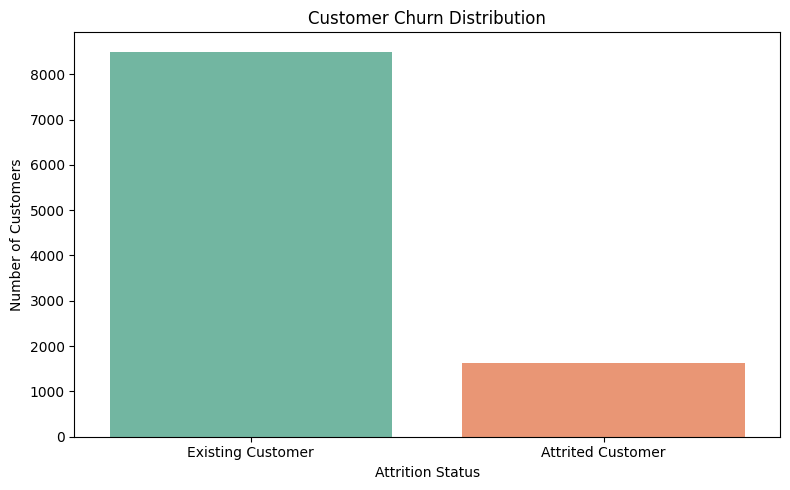

In [33]:
# Check churn distribution
churn_counts = df['Attrition_Flag'].value_counts()
churn_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_pct.round(2))

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition_Flag', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Attrition Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

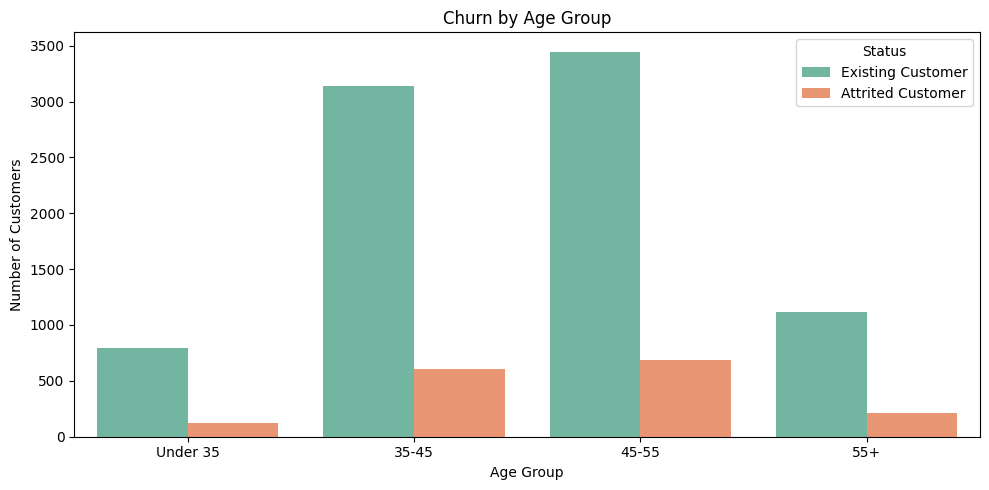

In [34]:
# Churn by age group
df['Age_Group'] = pd.cut(df['Customer_Age'], 
                          bins=[0, 35, 45, 55, 100],
                          labels=['Under 35', '35-45', '45-55', '55+'])

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Age_Group', hue='Attrition_Flag', palette='Set2')
plt.title('Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

Churn Rate by Age Group:
Age_Group
Under 35    13.28
35-45       16.19
45-55       16.64
55+         15.85
Name: Attrition_Flag, dtype: float64


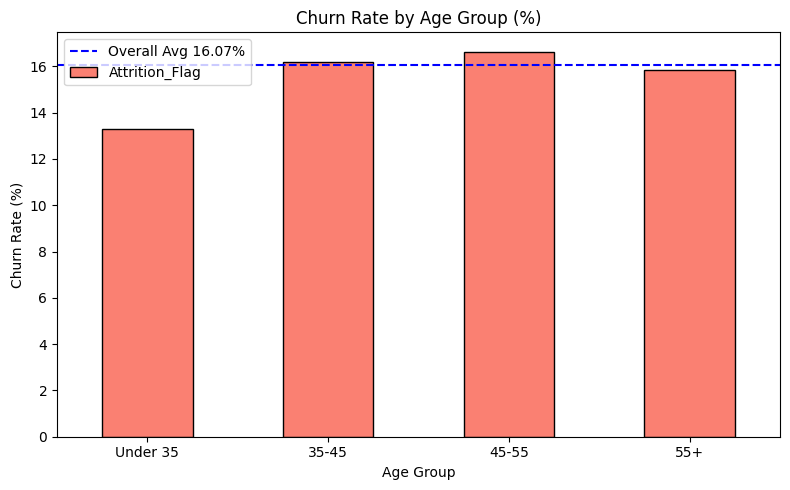

In [35]:
# Churn RATE by age group (not just count)
churn_rate_age = df.groupby('Age_Group')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2)

print("Churn Rate by Age Group:")
print(churn_rate_age)

# Visualize
plt.figure(figsize=(8, 5))
churn_rate_age.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Churn Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

Churn Rate by Gender:
Gender
F    17.36
M    14.62
Name: Attrition_Flag, dtype: float64


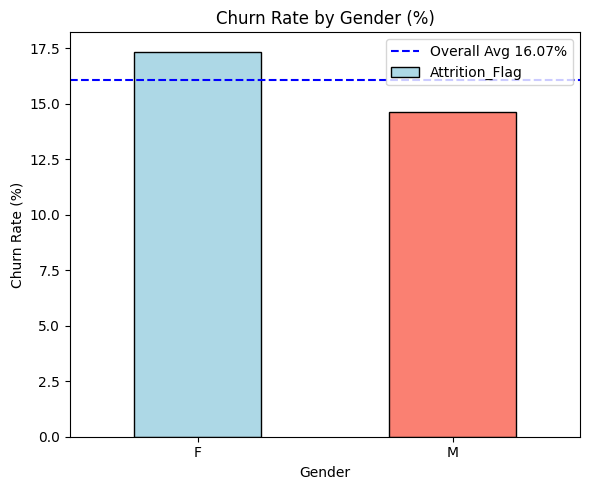

In [36]:
# Churn rate by gender
churn_rate_gender = df.groupby('Gender')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2)

print("Churn Rate by Gender:")
print(churn_rate_gender)

# Visualize
plt.figure(figsize=(6, 5))
churn_rate_gender.plot(kind='bar', color=['lightblue', 'salmon'], edgecolor='black')
plt.title('Churn Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

Churn Rate by Income Category:
Income_Category
$120K +           17.33
Less than $40K    17.19
Unknown           16.82
$80K - $120K      15.77
$40K - $60K       15.14
$60K - $80K       13.48
Name: Attrition_Flag, dtype: float64


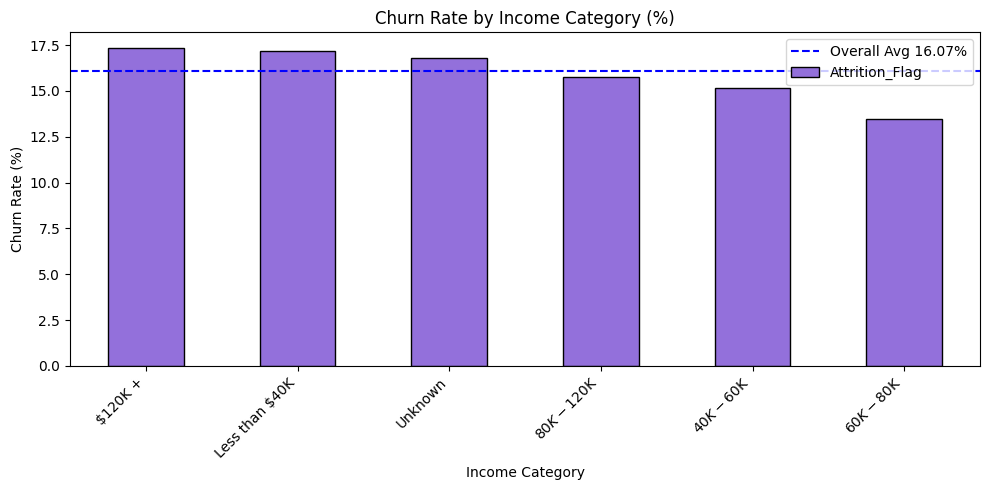

In [37]:
# Churn rate by income category
churn_rate_income = df.groupby('Income_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2).sort_values(ascending=False)

print("Churn Rate by Income Category:")
print(churn_rate_income)

# Visualize
plt.figure(figsize=(10, 5))
churn_rate_income.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Churn Rate by Income Category (%)')
plt.xlabel('Income Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

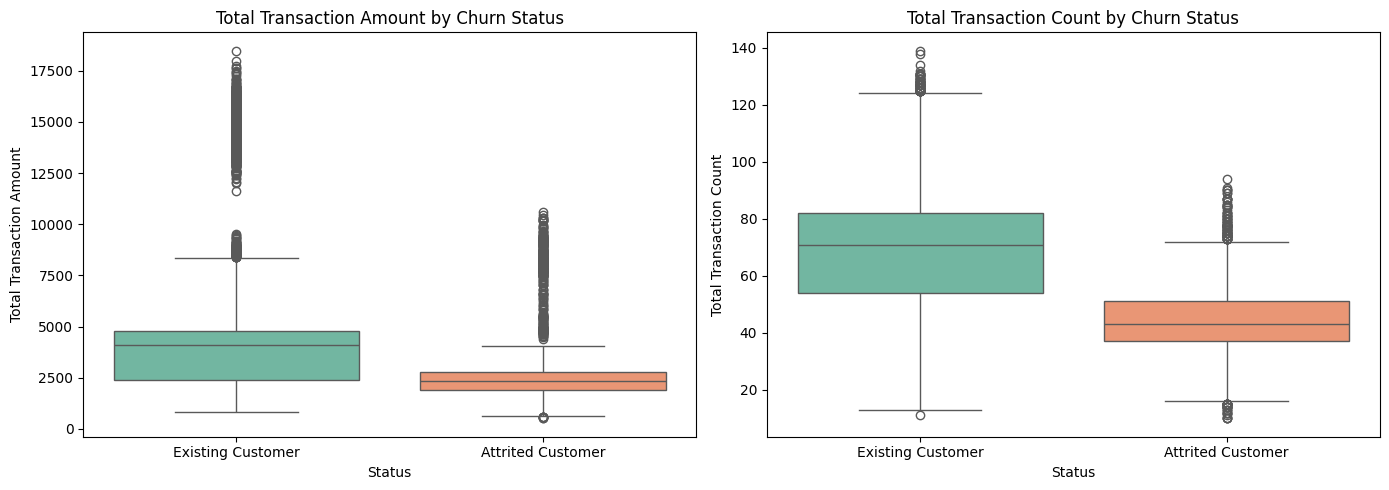

Average Transaction Amount:
Attrition_Flag
Attrited Customer    3095.03
Existing Customer    4654.66
Name: Total_Trans_Amt, dtype: float64

Average Transaction Count:
Attrition_Flag
Attrited Customer    44.93
Existing Customer    68.67
Name: Total_Trans_Ct, dtype: float64


In [40]:
# Compare transaction behavior between churned and retained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Transaction Amount
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Amt', hue='Attrition_Flag',legend=False,
            palette='Set2', ax=axes[0])
axes[0].set_title('Total Transaction Amount by Churn Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Total Transaction Amount')

# Total Transaction Count
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct', hue='Attrition_Flag',legend=False,
            palette='Set2', ax=axes[1])
axes[1].set_title('Total Transaction Count by Churn Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Total Transaction Count')

plt.tight_layout()
plt.show()

# Print averages
print("Average Transaction Amount:")
print(df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean().round(2))
print("\nAverage Transaction Count:")
print(df.groupby('Attrition_Flag')['Total_Trans_Ct'].mean().round(2))

C:\Users\yjain\AppData\Local\Temp\ipykernel_19404\2655485877.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Status')


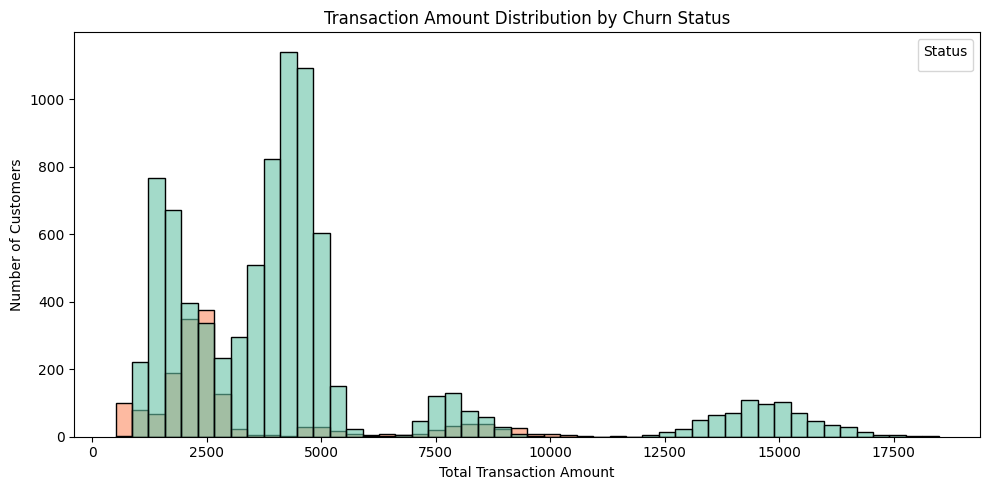

Transaction Amount Statistics by Churn Status:
                    count     mean      std    min      25%     50%      75%  \
Attrition_Flag                                                                 
Attrited Customer  1627.0  3095.03  2308.23  510.0  1903.50  2329.0  2772.00   
Existing Customer  8500.0  4654.66  3512.77  816.0  2384.75  4100.0  4781.25   

                       max  
Attrition_Flag              
Attrited Customer  10583.0  
Existing Customer  18484.0  


In [41]:
# Distribution of transaction amount by churn status
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Total_Trans_Amt', hue='Attrition_Flag', 
             bins=50, palette='Set2', alpha=0.6)
plt.title('Transaction Amount Distribution by Churn Status')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Number of Customers')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# Deeper stats
print("Transaction Amount Statistics by Churn Status:")
print(df.groupby('Attrition_Flag')['Total_Trans_Amt'].describe().round(2))

Churn Rate by Months Inactive:
Months_Inactive_12_mon
0    51.72
1     4.48
2    15.39
3    21.48
4    29.89
5    17.98
6    15.32
Name: Attrition_Flag, dtype: float64


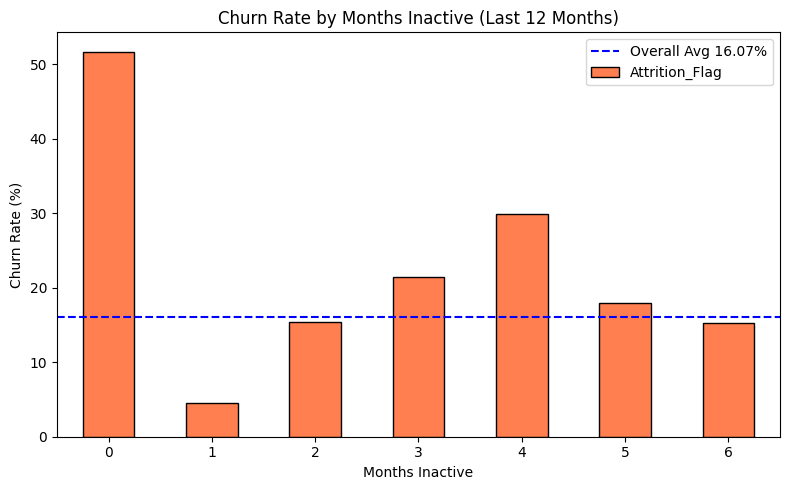

In [42]:
# Churn rate by months inactive
churn_rate_inactive = df.groupby('Months_Inactive_12_mon')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2)

print("Churn Rate by Months Inactive:")
print(churn_rate_inactive)

# Visualize
plt.figure(figsize=(8, 5))
churn_rate_inactive.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Months Inactive (Last 12 Months)')
plt.xlabel('Months Inactive')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Check sample sizes for each inactivity group
print("Customer Count by Months Inactive:")
print(df.groupby('Months_Inactive_12_mon')['Attrition_Flag'].count())

Customer Count by Months Inactive:
Months_Inactive_12_mon
0      29
1    2233
2    3282
3    3846
4     435
5     178
6     124
Name: Attrition_Flag, dtype: int64


Credit Limit Statistics by Churn Status:
                    count     mean      std     min     25%     50%       75%  \
Attrition_Flag                                                                  
Attrited Customer  1627.0  8136.04  9095.33  1438.3  2114.0  4178.0   9933.50   
Existing Customer  8500.0  8726.88  9084.97  1438.3  2602.0  4643.5  11252.75   

                       max  
Attrition_Flag              
Attrited Customer  34516.0  
Existing Customer  34516.0  


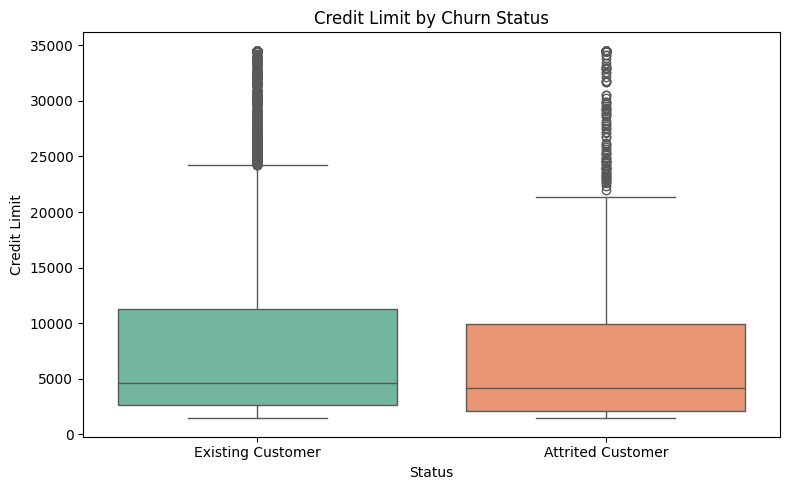

In [45]:
# Credit limit by churn status
print("Credit Limit Statistics by Churn Status:")
print(df.groupby('Attrition_Flag')['Credit_Limit'].describe().round(2))

# Visualize
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition_Flag', y='Credit_Limit', palette='Set2', hue='Attrition_Flag', legend=False   )
plt.title('Credit Limit by Churn Status')
plt.xlabel('Status')
plt.ylabel('Credit Limit')
plt.tight_layout()
plt.show()

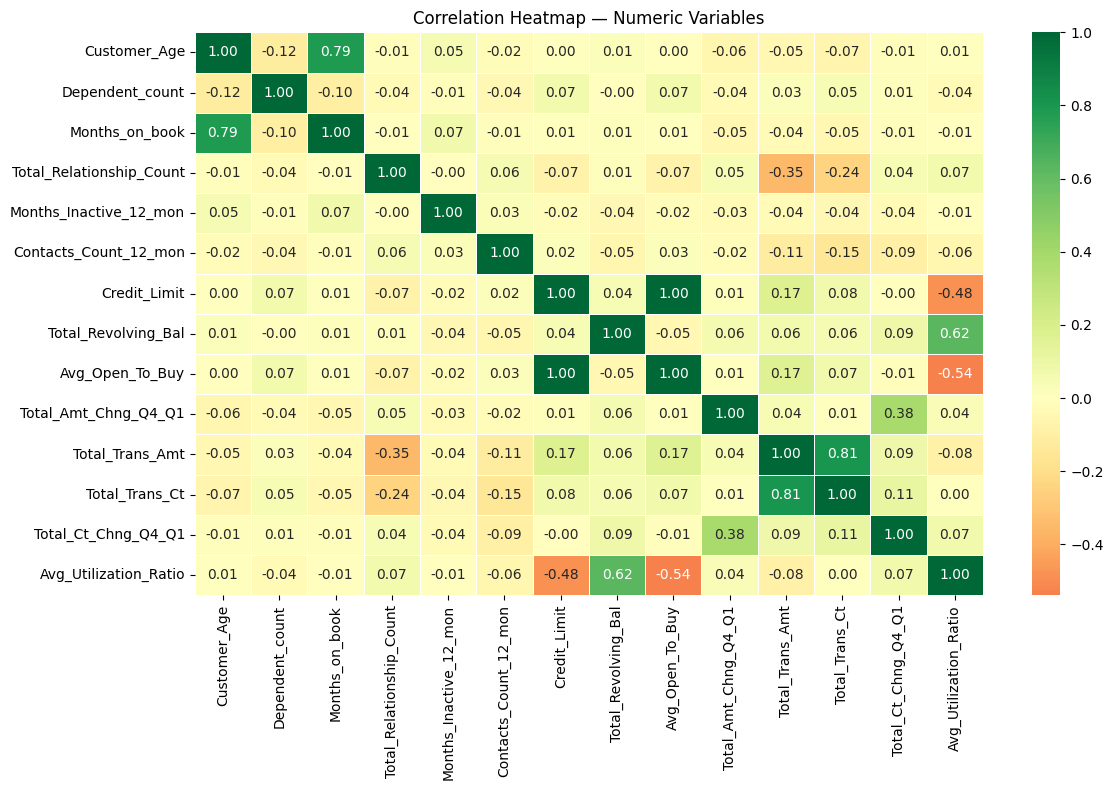

Correlation Matrix:
                          Customer_Age  Dependent_count  Months_on_book  \
Customer_Age                  1.000000        -0.122254        0.788912   
Dependent_count              -0.122254         1.000000       -0.103062   
Months_on_book                0.788912        -0.103062        1.000000   
Total_Relationship_Count     -0.010931        -0.039076       -0.009203   
Months_Inactive_12_mon        0.054361        -0.010768        0.074164   
Contacts_Count_12_mon        -0.018452        -0.040505       -0.010774   
Credit_Limit                  0.002476         0.068065        0.007507   
Total_Revolving_Bal           0.014780        -0.002688        0.008623   
Avg_Open_To_Buy               0.001151         0.068291        0.006732   
Total_Amt_Chng_Q4_Q1         -0.062042        -0.035439       -0.048959   
Total_Trans_Amt              -0.046446         0.025046       -0.038591   
Total_Trans_Ct               -0.067097         0.049912       -0.049819   
Total

In [47]:
# Correlation heatmap of numeric variables
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.show()
print("Correlation Matrix:")
print(correlation)

In [48]:
# Project Summary — Key Findings
print("=" * 60)
print("CUSTOMER CHURN ANALYSIS — KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"\nDataset: {df.shape[0]:,} customers, {df.shape[1]} variables")
print(f"Overall Churn Rate: 16.07%")
print("\nTop Churn Predictors:")
print("1. Transaction Amount — churned customers spend 33% less")
print("2. Transaction Count  — churned customers transact 35% less")
print("3. Inactivity         — 4+ months inactive = 29.89% churn rate")
print("4. Income Pattern     — U-shaped: highest churn at <$40K and $120K+")
print("5. Gender             — Female churn 17.36% vs Male 14.62%")
print("\nEarly Warning Signals:")
print("- Transaction amount declining below $3,095")
print("- Transaction count declining below 45")
print("- 3+ consecutive months of inactivity")
print("\nBusiness Recommendation:")
print("Build retention triggers around transaction activity decline")
print("and inactivity duration rather than demographic profiles.")
print("=" * 60)

CUSTOMER CHURN ANALYSIS — KEY FINDINGS SUMMARY

Dataset: 10,127 customers, 21 variables
Overall Churn Rate: 16.07%

Top Churn Predictors:
1. Transaction Amount — churned customers spend 33% less
2. Transaction Count  — churned customers transact 35% less
3. Inactivity         — 4+ months inactive = 29.89% churn rate
4. Income Pattern     — U-shaped: highest churn at <$40K and $120K+
5. Gender             — Female churn 17.36% vs Male 14.62%

Early Warning Signals:
- Transaction amount declining below $3,095
- Transaction count declining below 45
- 3+ consecutive months of inactivity

Business Recommendation:
Build retention triggers around transaction activity decline
and inactivity duration rather than demographic profiles.
